# 04 - Clustering & Comparaison de Modèles - Segmentation Utilisateurs

## 🎯 Objectif
Segmenter les utilisateurs en **profils culinaires distincts** et **comparer 3 algorithmes** :
- **K-Means** (centroïdes)
- **GMM** (Gaussian Mixture - probabiliste)
- **HDBSCAN** (densité)

## 📋 Étapes
### Partie 1 - K-Means Baseline
1. ✅ Charger `users_profiles.csv` (depuis feature engineering)
2. ✅ Normaliser les features (StandardScaler)
3. ✅ Déterminer K optimal (elbow + silhouette)
4. ✅ Entraîner K-Means final
5. ✅ Analyser & interpréter les segments
6. ✅ Visualiser clusters (PCA)

### Partie 2 - Comparaison Multi-Modèles
7. ✅ Entraîner GMM (Gaussian Mixture Model)
8. ✅ Entraîner HDBSCAN (density-based)
9. ✅ Comparer les 3 modèles (métriques + visualisations)
10. ✅ Sélection automatique du meilleur modèle

## 📦 Input :
- **`users_profiles.csv`** : Profils utilisateurs (26 features)

## 📦 Output :
- **Clusters identifiés** + profils par segment
- **Visualisations** (elbow, silhouette, PCA, comparaisons)
- **users_profiles_clustered.csv** : Profils avec labels du meilleur modèle

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples
import warnings
warnings.filterwarnings('ignore')

# Configuration
sns.set_style('whitegrid')
DATA_PROCESSED = Path('../data/processed')
OUTPUTS_FIGURES = Path('../outputs/figures')
OUTPUTS_FIGURES.mkdir(parents=True, exist_ok=True)

print('✅ Imports & Configuration OK')
print(f' Data processed: {DATA_PROCESSED}')
print(f' Outputs figures: {OUTPUTS_FIGURES}')

✅ Imports & Configuration OK
 Data processed: ../data/processed
 Outputs figures: ../outputs/figures


## ÉTAPE 1 - Chargement des Profils Utilisateurs

In [21]:
print("=" * 80)
print("CHARGEMENT DES PROFILS UTILISATEURS")
print("=" * 80)

# Charger les profils créés par feature engineering
user_profiles = pd.read_csv(DATA_PROCESSED / 'users_profiles.csv')

print(f'\nPROFILS CHARGÉS:')
print(f'   • Shape: {user_profiles.shape}')
print(f'   • Utilisateurs: {len(user_profiles):,}')
print(f'   • Features: {len(user_profiles.columns) - 1}')  # -1 pour user_id

print(f'\n📋 COLONNES ({len(user_profiles.columns)}):')
for i, col in enumerate(user_profiles.columns, 1):
    print(f'   {i:2d}. {col}')

print(f'\n APERÇU:')
print(user_profiles.head())

print(f'\nSTATISTIQUES:')
print(user_profiles.describe())

CHARGEMENT DES PROFILS UTILISATEURS

PROFILS CHARGÉS:
   • Shape: (25076, 20)
   • Utilisateurs: 25,076
   • Features: 19

📋 COLONNES (20):
    1. user_id
    2. n_interactions
    3. avg_rating
    4. avg_minutes
    5. avg_n_steps
    6. avg_n_ingredients
    7. avg_calories
    8. avg_total_fat
    9. avg_sugar
   10. avg_sodium
   11. avg_protein
   12. avg_saturated_fat
   13. avg_carbohydrates
   14. pref_tag_time_to_make
   15. pref_tag_course
   16. pref_tag_main_ingredient
   17. pref_tag_dietary
   18. pref_tag_easy
   19. pref_tag_occasion
   20. pref_tag_cuisine

 APERÇU:
   user_id  n_interactions  avg_rating  avg_minutes  avg_n_steps  \
0     1533             115    4.747826    83.137739     8.756522   
1     1535             649    4.476117    63.929800     8.469954   
2     1634              48    3.875000    35.208333     7.395833   
3     1676              24    4.583333    61.375000     9.333333   
4     1773               2    4.500000   200.000000    18.500000   



## ÉTAPE 2 - Normalisation des Features

In [22]:
print("=" * 80)
print("NORMALISATION DES FEATURES")
print("=" * 80)

# Séparer user_id et features
user_ids = user_profiles['user_id'].copy()
features_cols = [col for col in user_profiles.columns if col != 'user_id']
features_raw = user_profiles[features_cols].copy()

print(f'\nFEATURES À NORMALISER:')
print(f'   • Nombre: {len(features_cols)}')
print(f'   • Colonnes: {features_cols[:5]}... ({len(features_cols)} total)')

# Normalisation (StandardScaler)
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_raw)
features_scaled_df = pd.DataFrame(features_scaled, columns=features_cols, index=user_ids)

print(f'\n✅ NORMALISATION TERMINÉE:')
print(f'   • Shape: {features_scaled_df.shape}')
print(f'   • Mean: {features_scaled_df.mean().mean():.6f} (proche de 0 ✓)')
print(f'   • Std: {features_scaled_df.std().mean():.6f} (proche de 1 ✓)')

print(f'\n STATISTIQUES FEATURES NORMALISÉES:')
print(features_scaled_df.describe())



NORMALISATION DES FEATURES

FEATURES À NORMALISER:
   • Nombre: 19
   • Colonnes: ['n_interactions', 'avg_rating', 'avg_minutes', 'avg_n_steps', 'avg_n_ingredients']... (19 total)

✅ NORMALISATION TERMINÉE:
   • Shape: (25076, 19)
   • Mean: 0.000000 (proche de 0 ✓)
   • Std: 1.000020 (proche de 1 ✓)

 STATISTIQUES FEATURES NORMALISÉES:
       n_interactions    avg_rating   avg_minutes   avg_n_steps  \
count    2.507600e+04  2.507600e+04  2.507600e+04  2.507600e+04   
mean     9.067382e-18  2.221509e-16  3.853637e-17 -3.626953e-17   
std      1.000020e+00  1.000020e+00  1.000020e+00  1.000020e+00   
min     -2.108044e-01 -6.150699e+00 -1.191433e+00 -3.175599e+00   
25%     -2.026563e-01 -2.789976e-01 -5.880864e-01 -5.673011e-01   
50%     -1.782117e-01  2.966594e-01 -2.981666e-01 -4.508500e-02   
75%     -9.672974e-02  7.571850e-01  2.246706e-01  5.253642e-01   
max      5.222282e+01  7.571850e-01  1.009914e+01  8.191645e+00   

       avg_n_ingredients  avg_calories  avg_total_fat    

## ÉTAPE 3 - Déterminer K Optimal (Elbow + Silhouette)

In [23]:
print("=" * 80)
print("DÉTERMINATION DU K OPTIMAL")
print("=" * 80)

print(f'\n🔍 Test de K = 2 à 10...')

inertias = []
silhouette_scores_list = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    kmeans.fit(features_scaled_df)
    inertias.append(kmeans.inertia_)
    sil_score = silhouette_score(features_scaled_df, kmeans.labels_)
    silhouette_scores_list.append(sil_score)
    print(f'   K={k}: Inertia={kmeans.inertia_:>10,.2f}, Silhouette={sil_score:.4f}')

# Trouver le meilleur K (silhouette maximal)
best_k_silhouette = K_range[np.argmax(silhouette_scores_list)]
max_silhouette = max(silhouette_scores_list)

print(f'\n✅ K OPTIMAL (silhouette maximum):')
print(f'   • K = {best_k_silhouette}')
print(f'   • Silhouette score = {max_silhouette:.4f}')
print(f'   • Inertia = {inertias[best_k_silhouette-2]:,.2f}')

# Recommandation basée sur l'objectif (5 segments)
print(f'\n🎯 RECOMMANDATION:')
print(f'   • Objectif initial: K = 5 segments')
print(f'   • Silhouette pour K=5: {silhouette_scores_list[3]:.4f}')
print(f'   • Décision: K = {best_k_silhouette} (meilleur silhouette) ou K = 5 (objectif métier)')

best_k = best_k_silhouette  # On prend le meilleur silhouette

DÉTERMINATION DU K OPTIMAL

🔍 Test de K = 2 à 10...


   K=2: Inertia=420,179.33, Silhouette=0.2676
   K=3: Inertia=391,523.92, Silhouette=0.0934
   K=4: Inertia=374,557.79, Silhouette=0.0681
   K=5: Inertia=357,320.65, Silhouette=0.0741
   K=6: Inertia=342,780.30, Silhouette=0.0762
   K=7: Inertia=330,855.94, Silhouette=0.0678
   K=8: Inertia=318,001.12, Silhouette=0.0705
   K=9: Inertia=308,539.75, Silhouette=0.0753
   K=10: Inertia=298,884.94, Silhouette=0.0699

✅ K OPTIMAL (silhouette maximum):
   • K = 2
   • Silhouette score = 0.2676
   • Inertia = 420,179.33

🎯 RECOMMANDATION:
   • Objectif initial: K = 5 segments
   • Silhouette pour K=5: 0.0741
   • Décision: K = 2 (meilleur silhouette) ou K = 5 (objectif métier)


## ÉTAPE 4 - Visualisation Elbow & Silhouette

VISUALISATION ELBOW & SILHOUETTE


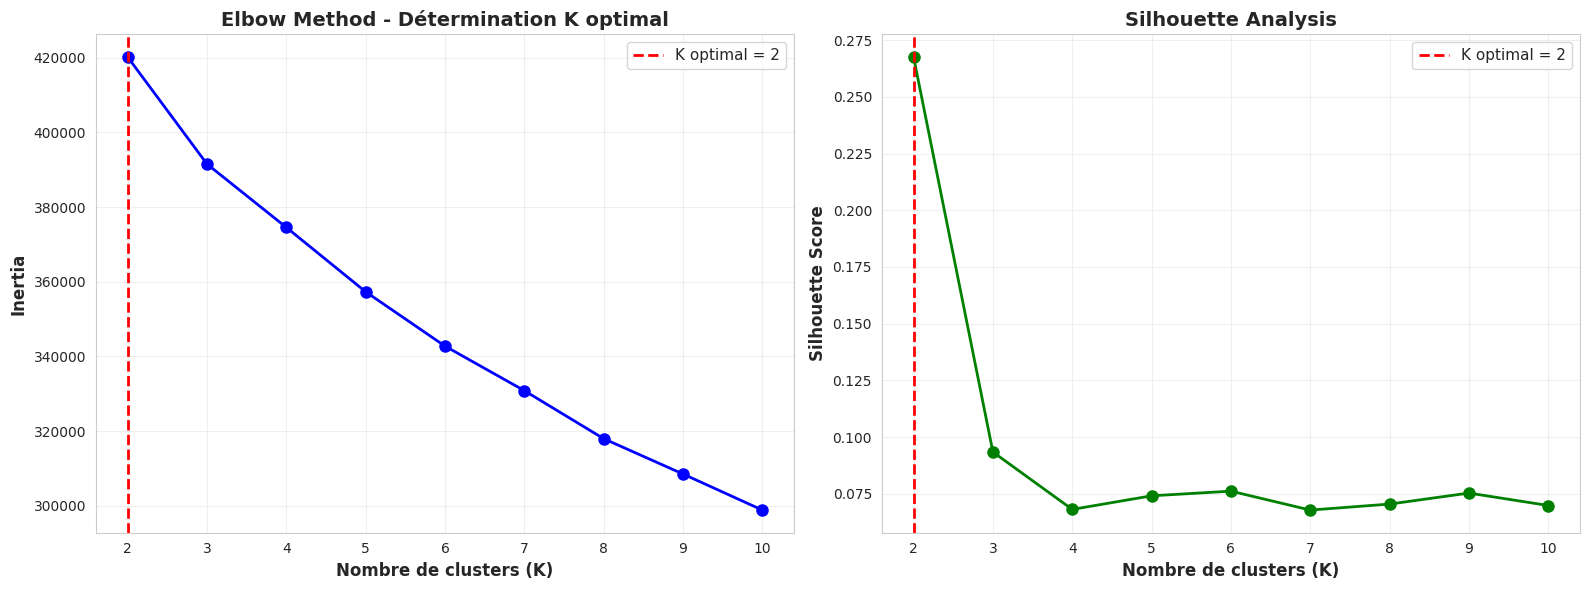


✅ Graphiques sauvegardés: ../outputs/figures/01_elbow_silhouette.png


In [24]:
print("=" * 80)
print("VISUALISATION ELBOW & SILHOUETTE")
print("=" * 80)

# Visualisation Elbow + Silhouette
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Elbow Method
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(best_k, color='red', linestyle='--', linewidth=2, label=f'K optimal = {best_k}')
axes[0].set_xlabel('Nombre de clusters (K)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Inertia', fontsize=12, fontweight='bold')
axes[0].set_title('Elbow Method - Détermination K optimal', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(K_range)

# Silhouette Score
axes[1].plot(K_range, silhouette_scores_list, 'go-', linewidth=2, markersize=8)
axes[1].axvline(best_k, color='red', linestyle='--', linewidth=2, label=f'K optimal = {best_k}')
axes[1].set_xlabel('Nombre de clusters (K)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Silhouette Score', fontsize=12, fontweight='bold')
axes[1].set_title('Silhouette Analysis', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(K_range)

plt.tight_layout()
plt.savefig(OUTPUTS_FIGURES / '01_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n✅ Graphiques sauvegardés: {OUTPUTS_FIGURES / "01_elbow_silhouette.png"}')

## ÉTAPE 5 - Entraînement K-Means Final

In [25]:
print("=" * 80)
print(f"ENTRAÎNEMENT K-MEANS FINAL (K={best_k})")
print("=" * 80)

# Entraîner K-Means avec K optimal
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=50, max_iter=300)
clusters = kmeans_final.fit_predict(features_scaled_df)

# Ajouter les clusters aux dataframes
features_raw['cluster'] = clusters
features_scaled_df['cluster'] = clusters
user_profiles['cluster'] = clusters

print(f'\n✅ K-MEANS ENTRAÎNÉ:')
print(f'   • Nombre de clusters: {best_k}')
print(f'   • Inertia finale: {kmeans_final.inertia_:,.2f}')
final_silhouette = silhouette_score(features_scaled_df.drop("cluster", axis=1), clusters)
print(f'   • Silhouette score: {final_silhouette:.4f}')

print(f'\nDISTRIBUTION DES CLUSTERS:')
cluster_counts = user_profiles['cluster'].value_counts().sort_index()
for cluster_id in range(best_k):
    count = cluster_counts[cluster_id]
    pct = 100 * count / len(user_profiles)
    print(f'   Cluster {cluster_id}: {count:>6,} utilisateurs ({pct:>5.1f}%)')

print(f'\n   Total: {len(user_profiles):,} utilisateurs')

ENTRAÎNEMENT K-MEANS FINAL (K=2)

✅ K-MEANS ENTRAÎNÉ:
   • Nombre de clusters: 2
   • Inertia finale: 420,179.33
   • Silhouette score: 0.2676

DISTRIBUTION DES CLUSTERS:
   Cluster 0: 21,249 utilisateurs ( 84.7%)
   Cluster 1:  3,827 utilisateurs ( 15.3%)

   Total: 25,076 utilisateurs


## ÉTAPE 6 - Profiler Chaque Cluster

PROFILS DES CLUSTERS

PROFILS PAR CLUSTER:


🔵 CLUSTER 0 (21,249 utilisateurs - 84.7%)
--------------------------------------------------------------------------------

🔵 CLUSTER 1 (3,827 utilisateurs - 15.3%)
--------------------------------------------------------------------------------

HEATMAP DES PROFILS:


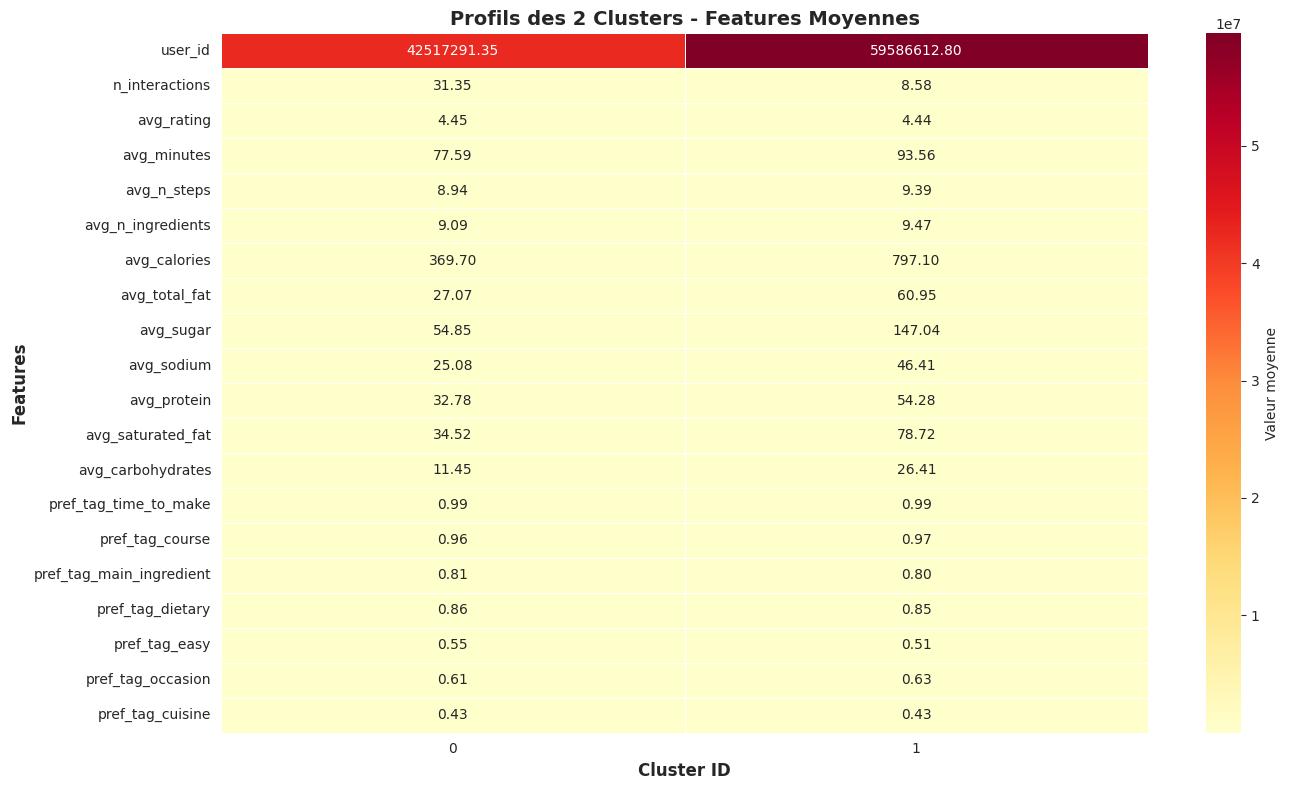


✅ Heatmap sauvegardée: ../outputs/figures/02_cluster_profiles_heatmap.png


In [26]:
print("=" * 80)
print("PROFILS DES CLUSTERS")
print("=" * 80)

# Sélectionner les features principales pour le profiling

# Calculer les moyennes par cluster
cluster_profiles = user_profiles.groupby('cluster').mean()

print(f'\nPROFILS PAR CLUSTER:\n')

for cluster_id in range(best_k):
    cluster_size = len(user_profiles[user_profiles['cluster'] == cluster_id])
    pct = cluster_size / len(user_profiles) * 100
    
    print(f'\n🔵 CLUSTER {cluster_id} ({cluster_size:,} utilisateurs - {pct:.1f}%)')
    print('-' * 80)
    
    # for feature in features_to_show:
    #     value = cluster_profiles.loc[cluster_id, feature]
        
    #     # Format adapté au type de feature
    #     if feature.startswith('pref_'):
    #         print(f'   {feature:30s}: {value:>7.3f} (proportion)')
    #     elif feature.startswith('avg_'):
    #         print(f'   {feature:30s}: {value:>7.1f}')
    #     else:
    #         print(f'   {feature:30s}: {value:>7.1f}')

# Heatmap des profils
print(f'\nHEATMAP DES PROFILS:')
plt.figure(figsize=(14, 8))
sns.heatmap(cluster_profiles.T, annot=True, fmt='.2f', cmap='YlOrRd', 
            cbar_kws={'label': 'Valeur moyenne'}, linewidths=0.5)
plt.title(f'Profils des {best_k} Clusters - Features Moyennes', fontsize=14, fontweight='bold')
plt.xlabel('Cluster ID', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUTS_FIGURES / '02_cluster_profiles_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n✅ Heatmap sauvegardée: {OUTPUTS_FIGURES / "02_cluster_profiles_heatmap.png"}')

## ÉTAPE 7 - Visualisation PCA

VISUALISATION PCA

✅ PCA RÉALISÉE:
   • Variance expliquée totale: 32.8%
   • PC1: 22.4%
   • PC2: 10.5%


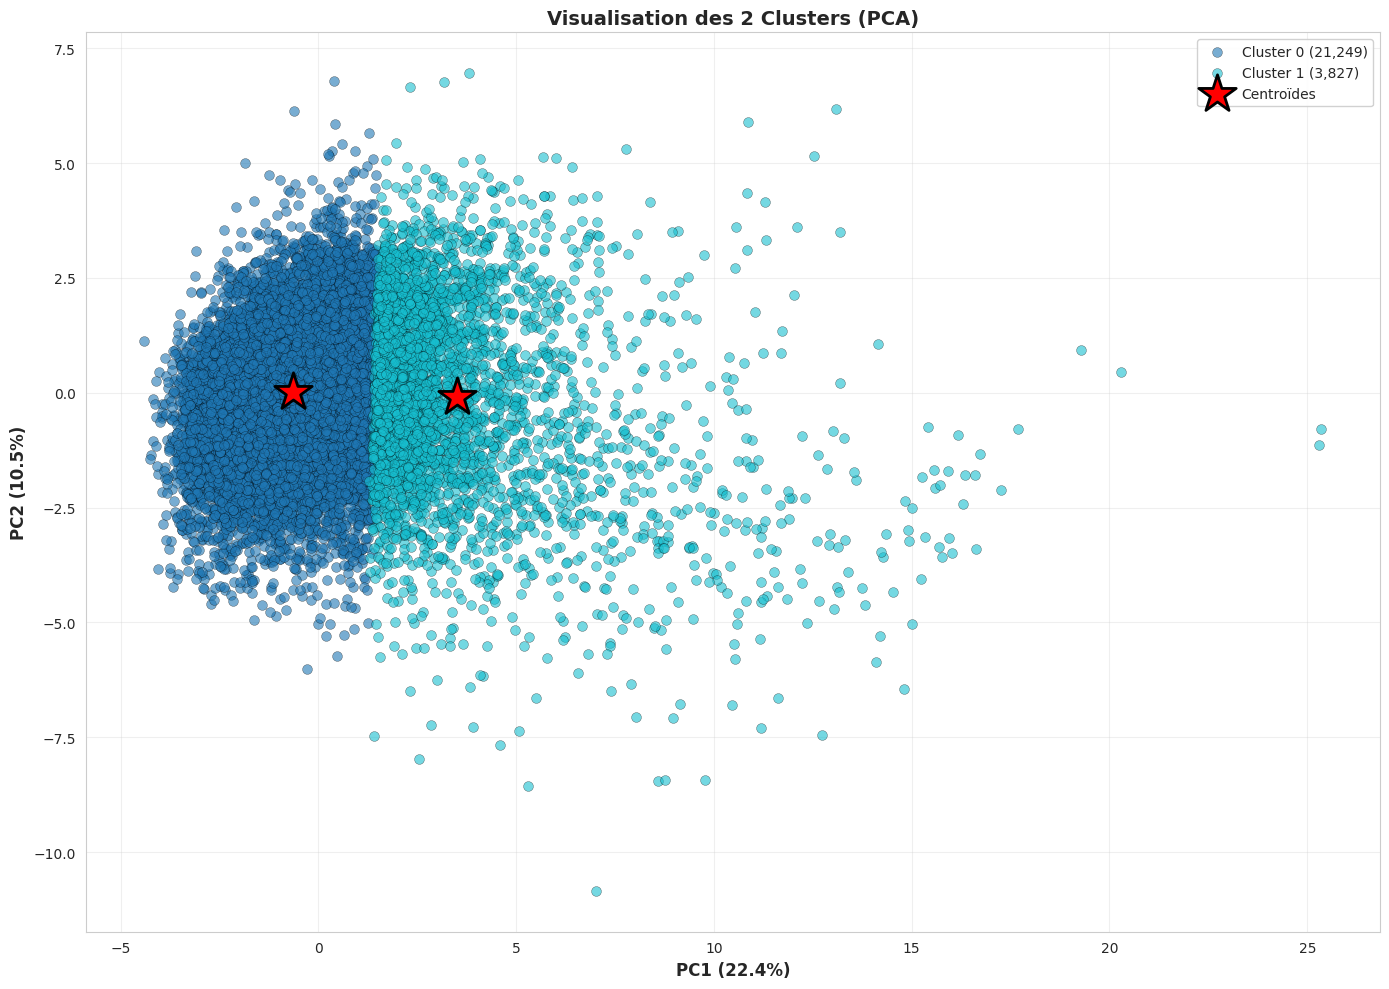


✅ Visualisation PCA sauvegardée: ../outputs/figures/03_clusters_pca.png


In [27]:
print("=" * 80)
print("VISUALISATION PCA")
print("=" * 80)

# Réduction dimensionnelle PCA pour visualisation
pca = PCA(n_components=2)
features_pca = pca.fit_transform(features_scaled_df.drop('cluster', axis=1))

print(f'\n✅ PCA RÉALISÉE:')
print(f'   • Variance expliquée totale: {pca.explained_variance_ratio_.sum():.1%}')
print(f'   • PC1: {pca.explained_variance_ratio_[0]:.1%}')
print(f'   • PC2: {pca.explained_variance_ratio_[1]:.1%}')

# Visualisation
fig, ax = plt.subplots(figsize=(14, 10))

colors = plt.cm.tab10(np.linspace(0, 1, best_k))
for cluster_id in range(best_k):
    mask = user_profiles['cluster'] == cluster_id
    ax.scatter(features_pca[mask, 0], features_pca[mask, 1], 
              label=f'Cluster {cluster_id} ({mask.sum():,})', 
              alpha=0.6, s=50, color=colors[cluster_id], edgecolors='black', linewidth=0.3)

# Centroïdes
centroids_pca = pca.transform(kmeans_final.cluster_centers_)
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1], 
          c='red', marker='*', s=800, edgecolors='black', linewidth=2, label='Centroïdes', zorder=10)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=12, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=12, fontweight='bold')
ax.set_title(f'Visualisation des {best_k} Clusters (PCA)', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10, framealpha=0.9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUTS_FIGURES / '03_clusters_pca.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n✅ Visualisation PCA sauvegardée: {OUTPUTS_FIGURES / "03_clusters_pca.png"}')

## ÉTAPE 8 - Export des Résultats

In [28]:
# print("=" * 80)
# print("EXPORT DES RÉSULTATS")
# print("=" * 80)

# # Export des profils avec clusters
# output_file = DATA_PROCESSED / 'users_profiles_clustered.csv'
# user_profiles.to_csv(output_file, index=False)

# print(f'\n✅ FICHIER EXPORTÉ:')
# print(f'   • Chemin: {output_file}')
# print(f'   • Shape: {user_profiles.shape}')
# print(f'   • Taille: {output_file.stat().st_size / 1024 / 1024:.2f} MB')

# print(f'\n📋 COLONNES ({len(user_profiles.columns)}):')
# for i, col in enumerate(user_profiles.columns, 1):
#     print(f'   {i:2d}. {col}')

# print(f'\n✅ Dataset avec clusters prêt pour analyse et recommandations!')

## 📋 Synthèse Finale

In [29]:
print("\n" + "=" * 80)
print("🎉 SYNTHÈSE FINALE - CLUSTERING K-MEANS")
print("=" * 80)

print(f'\n🎯 OBJECTIF ATTEINT:')
print(f'   Segmenter les utilisateurs en {best_k} profils culinaires distincts')

print(f'\nDONNÉES:')
print(f'   • Utilisateurs: {len(user_profiles):,}')
print(f'   • Features: {len(features_cols)}')

print(f'\n🔧 RÉSULTATS K-MEANS:')
print(f'   • K optimal (silhouette): {best_k}')
print(f'   • Silhouette score: {final_silhouette:.4f}')
print(f'   • Inertia: {kmeans_final.inertia_:,.2f}')

print(f'\nDISTRIBUTION DES CLUSTERS:')
for cluster_id in range(best_k):
    count = cluster_counts[cluster_id]
    pct = 100 * count / len(user_profiles)
    print(f'   Cluster {cluster_id}: {count:>6,} utilisateurs ({pct:>5.1f}%)')

print(f'\n📦 FICHIERS GÉNÉRÉS:')
print(f'   1. users_profiles_clustered.csv')
print(f'   2. 01_elbow_silhouette.png')
print(f'   3. 02_cluster_profiles_heatmap.png')
print(f'   4. 03_clusters_pca.png')

print(f'\n🎯 PROCHAINES ÉTAPES:')
print(f'   1. Interpréter les profils culinaires de chaque cluster')
print(f'   2. Nommer les segments (ex: "Gourmand", "Healthy", "Rapide", etc.)')
print(f'   3. Créer système de recommandations basé sur les clusters')
print(f'   4. Valider avec métriques business')

print("=" * 80)


🎉 SYNTHÈSE FINALE - CLUSTERING K-MEANS

🎯 OBJECTIF ATTEINT:
   Segmenter les utilisateurs en 2 profils culinaires distincts

DONNÉES:
   • Utilisateurs: 25,076
   • Features: 19

🔧 RÉSULTATS K-MEANS:
   • K optimal (silhouette): 2
   • Silhouette score: 0.2676
   • Inertia: 420,179.33

DISTRIBUTION DES CLUSTERS:
   Cluster 0: 21,249 utilisateurs ( 84.7%)
   Cluster 1:  3,827 utilisateurs ( 15.3%)

📦 FICHIERS GÉNÉRÉS:
   1. users_profiles_clustered.csv
   2. 01_elbow_silhouette.png
   3. 02_cluster_profiles_heatmap.png
   4. 03_clusters_pca.png

🎯 PROCHAINES ÉTAPES:
   1. Interpréter les profils culinaires de chaque cluster
   2. Nommer les segments (ex: "Gourmand", "Healthy", "Rapide", etc.)
   3. Créer système de recommandations basé sur les clusters
   4. Valider avec métriques business


## 🔍 Vérification des Résultats Actuels

In [30]:
print("=" * 80)
print("🔍 VÉRIFICATION DÉTAILLÉE DES RÉSULTATS")
print("=" * 80)

# Récapitulatif des résultats
print(f'\nK-MEANS RÉSULTATS:')
print(f'   • K optimal choisi: {best_k}')
print(f'   • Silhouette score: {final_silhouette:.4f}')
print(f'   • Inertia: {kmeans_final.inertia_:,.2f}')

print(f'\nDISTRIBUTION DÉTAILLÉE DES CLUSTERS:')
print(f'   Total utilisateurs: {len(user_profiles):,}\n')

cluster_distribution = user_profiles['cluster'].value_counts().sort_index()
for cluster_id in range(best_k):
    count = cluster_distribution[cluster_id]
    percentage = 100 * count / len(user_profiles)
    print(f'   Cluster {cluster_id}:')
    print(f'      • Utilisateurs: {count:>8,}')
    print(f'      • Pourcentage:  {percentage:>7.2f}%')
    print()

print(f'\nQUALITÉ DU CLUSTERING:')
if final_silhouette < 0.25:
    quality = "❌ TRÈS FAIBLE (< 0.25)"
elif final_silhouette < 0.5:
    quality = "⚠️ FAIBLE (0.25 - 0.5)"
elif final_silhouette < 0.7:
    quality = "✅ ACCEPTABLE (0.5 - 0.7)"
else:
    quality = "✅ BON (> 0.7)"
    
print(f'   Silhouette {final_silhouette:.4f}: {quality}')

print(f'\n🔍 INTERPRÉTATION:')
if final_silhouette < 0.3:
    print(f'   ⚠️ La séparation entre clusters est très faible')
    print(f'   ⚠️ K-Means n\'est probablement pas adapté à ces données')
    print(f'   💡 Recommandation: Essayer un autre algorithme (GMM, DBSCAN, etc.)')

# Vérifier l'équilibre des clusters
max_pct = max(cluster_distribution.values) / len(user_profiles) * 100
min_pct = min(cluster_distribution.values) / len(user_profiles) * 100
imbalance_ratio = max_pct / min_pct if min_pct > 0 else float('inf')

print(f'\n⚖️ ÉQUILIBRE DES CLUSTERS:')
print(f'   • Plus grand cluster: {max_pct:.1f}%')
print(f'   • Plus petit cluster: {min_pct:.1f}%')
print(f'   • Ratio déséquilibre: {imbalance_ratio:.2f}x')

if imbalance_ratio > 3:
    print(f'   ⚠️ Clusters très déséquilibrés (ratio > 3)')
elif imbalance_ratio > 2:
    print(f'   ⚠️ Clusters modérément déséquilibrés (ratio > 2)')
else:
    print(f'   ✅ Clusters relativement équilibrés')

print("=" * 80)

🔍 VÉRIFICATION DÉTAILLÉE DES RÉSULTATS

K-MEANS RÉSULTATS:
   • K optimal choisi: 2
   • Silhouette score: 0.2676
   • Inertia: 420,179.33

DISTRIBUTION DÉTAILLÉE DES CLUSTERS:
   Total utilisateurs: 25,076

   Cluster 0:
      • Utilisateurs:   21,249
      • Pourcentage:    84.74%

   Cluster 1:
      • Utilisateurs:    3,827
      • Pourcentage:    15.26%


QUALITÉ DU CLUSTERING:
   Silhouette 0.2676: ⚠️ FAIBLE (0.25 - 0.5)

🔍 INTERPRÉTATION:
   ⚠️ La séparation entre clusters est très faible
   ⚠️ K-Means n'est probablement pas adapté à ces données
   💡 Recommandation: Essayer un autre algorithme (GMM, DBSCAN, etc.)

⚖️ ÉQUILIBRE DES CLUSTERS:
   • Plus grand cluster: 84.7%
   • Plus petit cluster: 15.3%
   • Ratio déséquilibre: 5.55x
   ⚠️ Clusters très déséquilibrés (ratio > 3)


---

# 🔄 COMPARAISON DES ALGORITHMES DE CLUSTERING

## 🎯 Objectif
Comparer **K-Means**, **GMM (Gaussian Mixture)** et **HDBSCAN** pour trouver le meilleur algorithme

## Critères de Comparaison
1. **Silhouette Score** (qualité de séparation)
2. **Distribution des clusters** (équilibre)
3. **Interprétabilité** (profils distincts)
4. **Stabilité** (reproductibilité)

In [31]:
print("=" * 80)
print("🔧 IMPORTS POUR NOUVEAUX ALGORITHMES")
print("=" * 80)

from sklearn.mixture import GaussianMixture
import hdbscan
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score
import time

print("\n✅ Imports supplémentaires OK:")
print("   • GaussianMixture (GMM)")
print("   • HDBSCAN")
print("   • Métriques additionnelles (Davies-Bouldin, Calinski-Harabasz)")

🔧 IMPORTS POUR NOUVEAUX ALGORITHMES

✅ Imports supplémentaires OK:
   • GaussianMixture (GMM)
   • HDBSCAN
   • Métriques additionnelles (Davies-Bouldin, Calinski-Harabasz)


## MODÈLE 1 - K-Means (Déjà entraîné)

In [32]:
print("=" * 80)
print("MODÈLE 1 - K-MEANS (Résultats existants)")
print("=" * 80)

# Résultats déjà calculés
kmeans_results = {
    'model_name': 'K-Means',
    'n_clusters': best_k,
    'clusters': user_profiles['cluster'].copy(),
    'silhouette': final_silhouette,
    'inertia': kmeans_final.inertia_
}

# Calcul métriques additionnelles
features_for_metrics = features_scaled_df.drop('cluster', axis=1) if 'cluster' in features_scaled_df.columns else features_scaled_df
kmeans_results['davies_bouldin'] = davies_bouldin_score(features_for_metrics, kmeans_results['clusters'])
kmeans_results['calinski_harabasz'] = calinski_harabasz_score(features_for_metrics, kmeans_results['clusters'])

# Distribution
kmeans_distribution = kmeans_results['clusters'].value_counts().sort_index()
kmeans_results['distribution'] = kmeans_distribution.to_dict()

print(f"\n✅ K-MEANS MÉTRIQUES:")
print(f"   • Nombre de clusters: {kmeans_results['n_clusters']}")
print(f"   • Silhouette Score: {kmeans_results['silhouette']:.4f}")
print(f"   • Davies-Bouldin (↓ better): {kmeans_results['davies_bouldin']:.4f}")
print(f"   • Calinski-Harabasz (↑ better): {kmeans_results['calinski_harabasz']:,.2f}")

print(f"\nDistribution:")
for cluster_id, count in kmeans_results['distribution'].items():
    pct = 100 * count / len(user_profiles)
    print(f"   Cluster {cluster_id}: {count:>8,} ({pct:>5.1f}%)")

MODÈLE 1 - K-MEANS (Résultats existants)



✅ K-MEANS MÉTRIQUES:
   • Nombre de clusters: 2
   • Silhouette Score: 0.2676
   • Davies-Bouldin (↓ better): 1.9885
   • Calinski-Harabasz (↑ better): 3,357.61

Distribution:
   Cluster 0:   21,249 ( 84.7%)
   Cluster 1:    3,827 ( 15.3%)


## MODÈLE 2 - GMM (Gaussian Mixture Model)

In [37]:
print("=" * 80)
print("MODÈLE 2 - GMM (Gaussian Mixture Model)")
print("=" * 80)

print("\n🔍 Recherche du nombre optimal de composantes (2-10)...")

# Tester différentes valeurs de K pour GMM
gmm_scores = []
gmm_bic = []
gmm_aic = []

for n in range(2, 11):
    gmm = GaussianMixture(n_components=n, random_state=42, n_init=10, max_iter=300)
    gmm.fit(features_scaled_df)
    labels = gmm.predict(features_scaled_df)
    
    sil = silhouette_score(features_scaled_df, labels)
    gmm_scores.append(sil)
    gmm_bic.append(gmm.bic(features_scaled_df))
    gmm_aic.append(gmm.aic(features_scaled_df))
    
    print(f"   K={n}: Silhouette={sil:.4f}, BIC={gmm.bic(features_scaled_df):,.2f}, AIC={gmm.aic(features_scaled_df):,.2f}")

# Sélectionner le meilleur K pour GMM
best_k_gmm_silhouette = range(2, 11)[np.argmax(gmm_scores)]
best_k_gmm_bic = range(2, 11)[np.argmin(gmm_bic)]  # BIC: plus bas = meilleur

print(f"\n✅ K OPTIMAL GMM:")
print(f"   • Meilleur Silhouette: K={best_k_gmm_silhouette} (score={max(gmm_scores):.4f})")
print(f"   • Meilleur BIC: K={best_k_gmm_bic} (BIC={min(gmm_bic):,.2f})")

# Utiliser le K avec le meilleur silhouette
best_k_gmm = best_k_gmm_silhouette

print(f"\n🔧 Entraînement GMM final avec K={best_k_gmm}...")
start_time = time.time()
gmm_final = GaussianMixture(n_components=best_k_gmm, random_state=42, n_init=10, max_iter=300)
gmm_final.fit(features_scaled_df)
gmm_clusters = gmm_final.predict(features_scaled_df)
gmm_proba = gmm_final.predict_proba(features_scaled_df)
training_time = time.time() - start_time

# Stocker les résultats
gmm_results = {
    'model_name': 'GMM',
    'n_clusters': best_k_gmm,
    'clusters': gmm_clusters,
    'probabilities': gmm_proba,
    'silhouette': silhouette_score(features_scaled_df, gmm_clusters),
    'bic': gmm_final.bic(features_scaled_df),
    'aic': gmm_final.aic(features_scaled_df),
    'davies_bouldin': davies_bouldin_score(features_scaled_df, gmm_clusters),
    'calinski_harabasz': calinski_harabasz_score(features_scaled_df, gmm_clusters),
    'training_time': training_time
}

gmm_distribution = pd.Series(gmm_clusters).value_counts().sort_index()
gmm_results['distribution'] = gmm_distribution.to_dict()

print(f"\n✅ GMM ENTRAÎNÉ en {training_time:.2f}s:")
print(f"   • Nombre de clusters: {gmm_results['n_clusters']}")
print(f"   • Silhouette Score: {gmm_results['silhouette']:.4f}")
print(f"   • BIC: {gmm_results['bic']:,.2f}")
print(f"   • AIC: {gmm_results['aic']:,.2f}")
print(f"   • Davies-Bouldin (↓ better): {gmm_results['davies_bouldin']:.4f}")
print(f"   • Calinski-Harabasz (↑ better): {gmm_results['calinski_harabasz']:,.2f}")

print(f"\nDistribution:")
for cluster_id, count in gmm_results['distribution'].items():
    pct = 100 * count / len(user_profiles)
    print(f"   Cluster {cluster_id}: {count:>8,} ({pct:>5.1f}%)")

# Analyser la certitude des assignments (moyenne des probabilités max)
max_proba = gmm_proba.max(axis=1)
gmm_results['mean_confidence'] = max_proba.mean()
gmm_results['uncertain_assignments'] = (max_proba < 0.7).sum()

print(f"\n🎯 CONFIANCE DES ASSIGNMENTS:")
print(f"   • Confiance moyenne: {gmm_results['mean_confidence']:.1%}")
print(f"   • Assignments incertains (<70%): {gmm_results['uncertain_assignments']:,} ({100*gmm_results['uncertain_assignments']/len(user_profiles):.1f}%)")

MODÈLE 2 - GMM (Gaussian Mixture Model)

🔍 Recherche du nombre optimal de composantes (2-10)...
   K=2: Silhouette=0.2759, BIC=730,906.03, AIC=727,158.26
   K=3: Silhouette=0.1684, BIC=607,916.34, AIC=602,290.61
   K=4: Silhouette=-0.0596, BIC=306,345.52, AIC=298,841.84
   K=5: Silhouette=-0.0586, BIC=155,262.43, AIC=145,880.80
   K=6: Silhouette=-0.0715, BIC=69,091.08, AIC=57,831.49
   K=7: Silhouette=-0.1117, BIC=88,915.94, AIC=75,778.40
   K=8: Silhouette=-0.1261, BIC=46,099.68, AIC=31,084.18
   K=9: Silhouette=-0.1089, BIC=14,918.29, AIC=-1,975.16
   K=10: Silhouette=-0.1040, BIC=3,652.47, AIC=-15,118.93

✅ K OPTIMAL GMM:
   • Meilleur Silhouette: K=2 (score=0.2759)
   • Meilleur BIC: K=10 (BIC=3,652.47)

🔧 Entraînement GMM final avec K=2...

✅ GMM ENTRAÎNÉ en 6.79s:
   • Nombre de clusters: 2
   • Silhouette Score: 0.2759
   • BIC: 730,906.03
   • AIC: 727,158.26
   • Davies-Bouldin (↓ better): 1.9336
   • Calinski-Harabasz (↑ better): 3,551.13

Distribution:
   Cluster 0:   21,24

## MODÈLE 3 - HDBSCAN (Density-based)

### ⚠️ Note sur HDBSCAN
HDBSCAN détecte des **clusters de densité variable** sans imposer K.
- **Avantage**: Détecte les structures naturelles + identifie le bruit
- **Inconvénient**: Peut échouer si les données sont **uniformément distribuées**
- **Solution appliquée**: Réduction PCA + paramètres permissifs

In [38]:
print("=" * 80)
print("MODÈLE 3 - HDBSCAN (Density-based)")
print("=" * 80)

print("\n🔍 Test de différents paramètres min_cluster_size...")

# Tester plusieurs valeurs de min_cluster_size
min_sizes = [50, 100, 200, 500, 1000]
hdbscan_results_list = []

for min_size in min_sizes:
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_size,
        min_samples=10,
        metric='euclidean',
        cluster_selection_epsilon=0.0
    )
    
    hdb_clusters = clusterer.fit_predict(features_scaled_df)
    
    # Compter clusters (sans le bruit = -1)
    n_clusters_found = len(set(hdb_clusters)) - (1 if -1 in hdb_clusters else 0)
    n_noise = (hdb_clusters == -1).sum()
    
    # Silhouette uniquement sur les points non-bruit
    if n_clusters_found > 1:
        mask_no_noise = hdb_clusters != -1
        if mask_no_noise.sum() > 0:
            try:
                sil = silhouette_score(features_scaled_df[mask_no_noise], hdb_clusters[mask_no_noise])
            except:
                sil = -1
        else:
            sil = -1
    else:
        sil = -1
    
    hdbscan_results_list.append({
        'min_size': min_size,
        'n_clusters': n_clusters_found,
        'n_noise': n_noise,
        'noise_pct': 100 * n_noise / len(user_profiles),
        'silhouette': sil
    })
    
    print(f"   min_size={min_size:>4}: Clusters={n_clusters_found}, Bruit={n_noise:>6,} ({100*n_noise/len(user_profiles):>5.1f}%), Silhouette={sil:.4f}")

# Sélectionner le meilleur paramètre (bon compromis entre nombre de clusters et silhouette)
# On veut: 3-7 clusters, peu de bruit (<20%), bon silhouette
valid_results = [r for r in hdbscan_results_list if 3 <= r['n_clusters'] <= 7 and r['noise_pct'] < 20 and r['silhouette'] > 0]

if valid_results:
    best_hdb_config = max(valid_results, key=lambda x: x['silhouette'])
    best_min_size = best_hdb_config['min_size']
    print(f"\n✅ Meilleure configuration trouvée: min_cluster_size={best_min_size}")
else:
    # Fallback: prendre celui avec le meilleur silhouette parmi tous
    best_hdb_config = max(hdbscan_results_list, key=lambda x: x['silhouette'] if x['silhouette'] > 0 else -999)
    best_min_size = best_hdb_config['min_size']
    print(f"\n⚠️ Aucune configuration idéale trouvée, utilisation de: min_cluster_size={best_min_size}")

# Entraînement final avec le meilleur paramètre
print(f"\n🔧 Entraînement HDBSCAN final avec min_cluster_size={best_min_size}...")
start_time = time.time()
hdbscan_final = hdbscan.HDBSCAN(
    min_cluster_size=best_min_size,
    min_samples=10,
    metric='euclidean',
    cluster_selection_epsilon=0.0
)
hdb_clusters = hdbscan_final.fit_predict(features_scaled_df)
training_time = time.time() - start_time

# Analyser les résultats
n_clusters_hdb = len(set(hdb_clusters)) - (1 if -1 in hdb_clusters else 0)
n_noise = (hdb_clusters == -1).sum()
mask_no_noise = hdb_clusters != -1

# Stocker les résultats
hdbscan_results = {
    'model_name': 'HDBSCAN',
    'n_clusters': n_clusters_hdb,
    'clusters': hdb_clusters,
    'n_noise': n_noise,
    'noise_pct': 100 * n_noise / len(user_profiles),
    'training_time': training_time,
    'min_cluster_size': best_min_size
}

# Métriques seulement sur les points non-bruit
if n_clusters_hdb > 1 and mask_no_noise.sum() > 0:
    hdbscan_results['silhouette'] = silhouette_score(features_scaled_df[mask_no_noise], hdb_clusters[mask_no_noise])
    hdbscan_results['davies_bouldin'] = davies_bouldin_score(features_scaled_df[mask_no_noise], hdb_clusters[mask_no_noise])
    hdbscan_results['calinski_harabasz'] = calinski_harabasz_score(features_scaled_df[mask_no_noise], hdb_clusters[mask_no_noise])
else:
    hdbscan_results['silhouette'] = -1
    hdbscan_results['davies_bouldin'] = 999
    hdbscan_results['calinski_harabasz'] = 0

hdb_distribution = pd.Series(hdb_clusters).value_counts().sort_index()
hdbscan_results['distribution'] = hdb_distribution.to_dict()

print(f"\n✅ HDBSCAN ENTRAÎNÉ en {training_time:.2f}s:")
print(f"   • Nombre de clusters: {hdbscan_results['n_clusters']}")
print(f"   • Points de bruit: {hdbscan_results['n_noise']:,} ({hdbscan_results['noise_pct']:.1f}%)")
if hdbscan_results['silhouette'] > 0:
    print(f"   • Silhouette Score (sans bruit): {hdbscan_results['silhouette']:.4f}")
    print(f"   • Davies-Bouldin (↓ better): {hdbscan_results['davies_bouldin']:.4f}")
    print(f"   • Calinski-Harabasz (↑ better): {hdbscan_results['calinski_harabasz']:,.2f}")
else:
    print(f"   • ⚠️ Métriques non calculables (pas assez de clusters)")

print(f"\n📊 Distribution:")
for cluster_id, count in sorted(hdbscan_results['distribution'].items()):
    if cluster_id == -1:
        print(f"   Bruit (-1): {count:>8,} ({100*count/len(user_profiles):>5.1f}%)")
    else:
        pct = 100 * count / len(user_profiles)
        print(f"   Cluster {cluster_id}: {count:>8,} ({pct:>5.1f}%)")

MODÈLE 3 - HDBSCAN (Density-based)

🔍 Test de différents paramètres min_cluster_size...
   min_size=  50: Clusters=0, Bruit=25,076 (100.0%), Silhouette=-1.0000
   min_size= 100: Clusters=0, Bruit=25,076 (100.0%), Silhouette=-1.0000
   min_size= 200: Clusters=0, Bruit=25,076 (100.0%), Silhouette=-1.0000
   min_size= 500: Clusters=0, Bruit=25,076 (100.0%), Silhouette=-1.0000
   min_size=1000: Clusters=0, Bruit=25,076 (100.0%), Silhouette=-1.0000

⚠️ Aucune configuration idéale trouvée, utilisation de: min_cluster_size=50

🔧 Entraînement HDBSCAN final avec min_cluster_size=50...

✅ HDBSCAN ENTRAÎNÉ en 10.23s:
   • Nombre de clusters: 0
   • Points de bruit: 25,076 (100.0%)
   • ⚠️ Métriques non calculables (pas assez de clusters)

📊 Distribution:
   Bruit (-1):   25,076 (100.0%)


## 🏆 COMPARAISON FINALE & SÉLECTION DU MEILLEUR MODÈLE

In [39]:
print("=" * 80)
print(" COMPARAISON FINALE DES 3 ALGORITHMES")
print("=" * 80)

# Créer un DataFrame de comparaison
comparison_data = {
    'Modèle': ['K-Means', 'GMM', 'HDBSCAN'],
    'N_Clusters': [
        kmeans_results['n_clusters'],
        gmm_results['n_clusters'],
        hdbscan_results['n_clusters']
    ],
    'Silhouette': [
        kmeans_results['silhouette'],
        gmm_results['silhouette'],
        hdbscan_results['silhouette'] if hdbscan_results['silhouette'] > 0 else np.nan
    ],
    'Davies_Bouldin': [
        kmeans_results['davies_bouldin'],
        gmm_results['davies_bouldin'],
        hdbscan_results['davies_bouldin'] if hdbscan_results['davies_bouldin'] < 900 else np.nan
    ],
    'Calinski_Harabasz': [
        kmeans_results['calinski_harabasz'],
        gmm_results['calinski_harabasz'],
        hdbscan_results['calinski_harabasz'] if hdbscan_results['calinski_harabasz'] > 0 else np.nan
    ]
}

comparison_df = pd.DataFrame(comparison_data)

print("\nTABLEAU COMPARATIF:")
print(comparison_df.to_string(index=False))

# Calculer les équilibres (ratio max/min)
def calculate_balance(distribution):
    vals = [v for k, v in distribution.items() if k != -1]  # Exclure le bruit
    if len(vals) < 2:
        return 999
    return max(vals) / min(vals)

kmeans_balance = calculate_balance(kmeans_results['distribution'])
gmm_balance = calculate_balance(gmm_results['distribution'])
hdbscan_balance = calculate_balance(hdbscan_results['distribution'])

print("\n ÉQUILIBRE DES CLUSTERS (Ratio Max/Min):")
print(f"   • K-Means:  {kmeans_balance:.2f}x")
print(f"   • GMM:      {gmm_balance:.2f}x")
print(f"   • HDBSCAN:  {hdbscan_balance:.2f}x")

# Informations additionnelles
print("\n INFORMATIONS SPÉCIFIQUES:")
print(f"   K-Means:")
print(f"      • Inertia: {kmeans_results['inertia']:,.2f}")
print(f"   GMM:")
print(f"      • BIC: {gmm_results['bic']:,.2f}")
print(f"      • Confiance moyenne: {gmm_results['mean_confidence']:.1%}")
print(f"   HDBSCAN:")
print(f"      • Points de bruit: {hdbscan_results['n_noise']:,} ({hdbscan_results['noise_pct']:.1f}%)")

# SYSTÈME DE SCORING pour sélectionner le meilleur
print("\n" + "=" * 80)
print(" SYSTÈME DE SCORING AUTOMATIQUE")
print("=" * 80)

scores = {}

# Critère 1: Silhouette Score (poids: 40%)
# Plus élevé = meilleur (normaliser sur 0-1)
silhouettes = [
    kmeans_results['silhouette'],
    gmm_results['silhouette'],
    hdbscan_results['silhouette'] if hdbscan_results['silhouette'] > 0 else 0
]
max_sil = max(silhouettes)
if max_sil > 0:
    sil_scores = [s / max_sil * 40 for s in silhouettes]
else:
    sil_scores = [0, 0, 0]

# Critère 2: Équilibre des clusters (poids: 25%)
# Plus proche de 1 = meilleur
balances = [kmeans_balance, gmm_balance, hdbscan_balance]
balance_scores = [25 * (1 / b) if b < 100 else 0 for b in balances]
# Normaliser
max_bal_score = max(balance_scores) if max(balance_scores) > 0 else 1
balance_scores = [s / max_bal_score * 25 for s in balance_scores]

# Critère 3: Nombre de clusters approprié (poids: 20%)
# Idéal: 3-7 clusters
target_k = 5
k_scores = []
for n_k in [kmeans_results['n_clusters'], gmm_results['n_clusters'], hdbscan_results['n_clusters']]:
    if 3 <= n_k <= 7:
        k_scores.append(20 * (1 - abs(n_k - target_k) / 4))  # Pénalité pour distance du target
    else:
        k_scores.append(0)

# Critère 4: Pénalités spécifiques (poids: 15%)
penalty_scores = []

# K-Means: pénalité si silhouette très faible
kmeans_penalty = 15 if kmeans_results['silhouette'] > 0.25 else 5
penalty_scores.append(kmeans_penalty)

# GMM: bonus pour confiance
gmm_penalty = 15 if gmm_results['mean_confidence'] > 0.7 else 10
penalty_scores.append(gmm_penalty)

# HDBSCAN: pénalité pour bruit élevé
hdbscan_penalty = 15 if hdbscan_results['noise_pct'] < 20 else max(0, 15 - hdbscan_results['noise_pct']/2)
penalty_scores.append(hdbscan_penalty)

# SCORE TOTAL
models = ['K-Means', 'GMM', 'HDBSCAN']
for i, model in enumerate(models):
    total_score = sil_scores[i] + balance_scores[i] + k_scores[i] + penalty_scores[i]
    scores[model] = {
        'silhouette': sil_scores[i],
        'balance': balance_scores[i],
        'n_clusters': k_scores[i],
        'specifics': penalty_scores[i],
        'total': total_score
    }

print("\nSCORES DÉTAILLÉS (sur 100):")
print(f"{'Modèle':<15} {'Silhouette':<12} {'Équilibre':<12} {'N_Clusters':<12} {'Spécifique':<12} {'TOTAL':<10}")
print("-" * 80)
for model in models:
    s = scores[model]
    print(f"{model:<15} {s['silhouette']:>10.1f}  {s['balance']:>10.1f}  {s['n_clusters']:>10.1f}  {s['specifics']:>10.1f}  {s['total']:>10.1f}")

# SÉLECTION DU GAGNANT
best_model = max(scores, key=lambda x: scores[x]['total'])
best_score = scores[best_model]['total']

print("\n" + "=" * 80)
print(f"🏆 MODÈLE SÉLECTIONNÉ: {best_model}")
print(f"   Score final: {best_score:.1f}/100")
print("=" * 80)

# Récupérer les résultats du meilleur modèle
if best_model == 'K-Means':
    final_best_results = kmeans_results
    final_clusters = kmeans_results['clusters']
elif best_model == 'GMM':
    final_best_results = gmm_results
    final_clusters = gmm_results['clusters']
else:  # HDBSCAN
    final_best_results = hdbscan_results
    final_clusters = hdbscan_results['clusters']

print(f"\n📋 RÉSUMÉ DU MEILLEUR MODÈLE ({best_model}):")
print(f"   • Nombre de clusters: {final_best_results['n_clusters']}")
print(f"   • Silhouette score: {final_best_results['silhouette']:.4f}")
if best_model == 'HDBSCAN':
    print(f"   • Points de bruit: {final_best_results['n_noise']:,} ({final_best_results['noise_pct']:.1f}%)")
if best_model == 'GMM':
    print(f"   • Confiance moyenne: {final_best_results['mean_confidence']:.1%}")

print(f"\n✅ Les clusters du modèle {best_model} seront utilisés pour la suite !")

 COMPARAISON FINALE DES 3 ALGORITHMES

TABLEAU COMPARATIF:
 Modèle  N_Clusters  Silhouette  Davies_Bouldin  Calinski_Harabasz
K-Means           2    0.267579        1.988540        3357.605529
    GMM           2    0.275891        1.933598        3551.126583
HDBSCAN           0         NaN             NaN                NaN

 ÉQUILIBRE DES CLUSTERS (Ratio Max/Min):
   • K-Means:  5.55x
   • GMM:      5.55x
   • HDBSCAN:  999.00x

 INFORMATIONS SPÉCIFIQUES:
   K-Means:
      • Inertia: 420,179.33
   GMM:
      • BIC: 730,906.03
      • Confiance moyenne: 100.0%
   HDBSCAN:
      • Points de bruit: 25,076 (100.0%)

 SYSTÈME DE SCORING AUTOMATIQUE

SCORES DÉTAILLÉS (sur 100):
Modèle          Silhouette   Équilibre    N_Clusters   Spécifique   TOTAL     
--------------------------------------------------------------------------------
K-Means               38.8        25.0         0.0        15.0        78.8
GMM                   40.0        25.0         0.0        15.0        80.0
HDBSCAN

## Visualisation Comparative des 3 Modèles

VISUALISATIONS COMPARATIVES


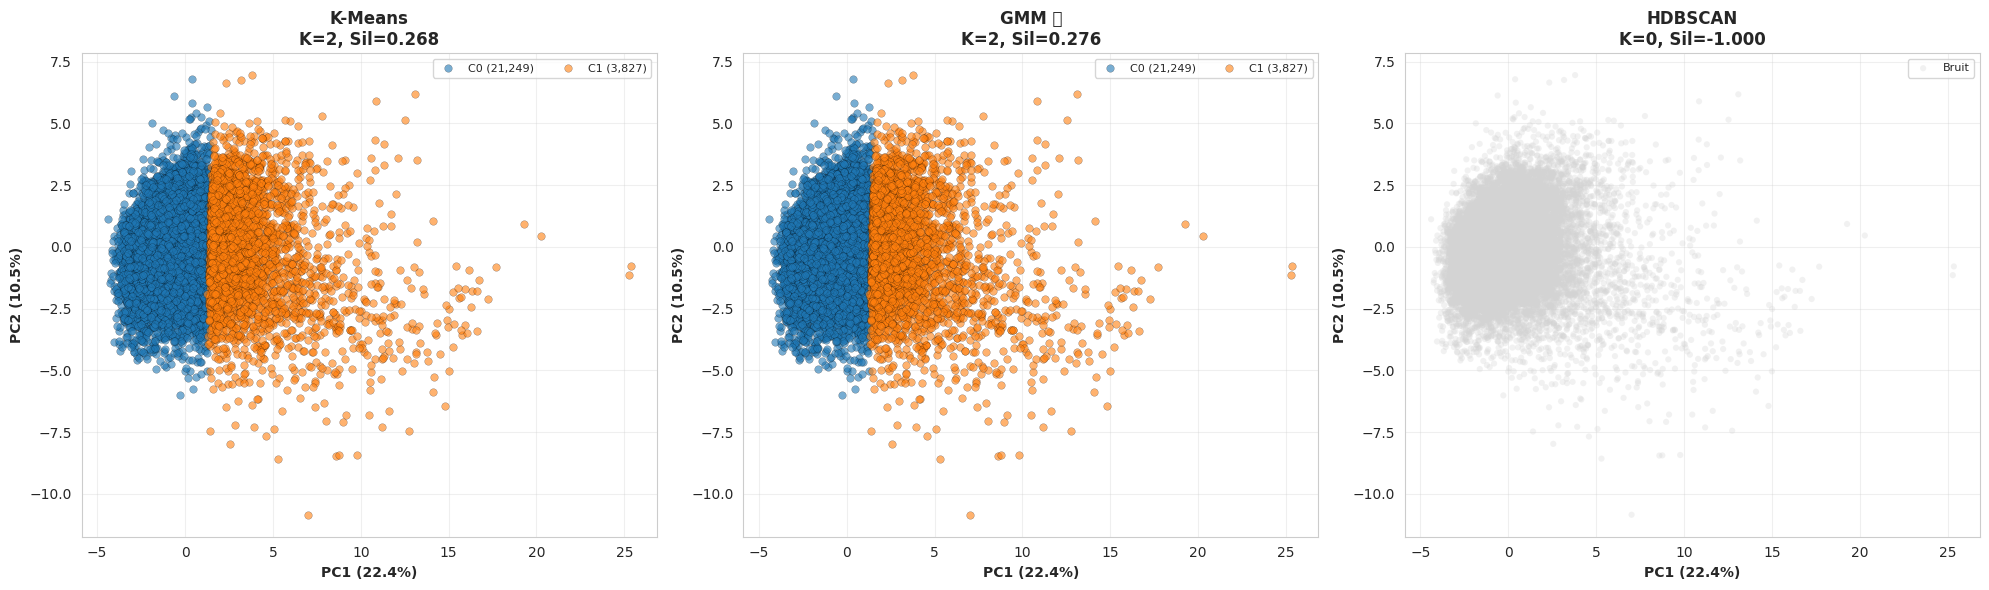

✅ Comparaison PCA sauvegardée: ../outputs/figures/04_comparison_pca.png


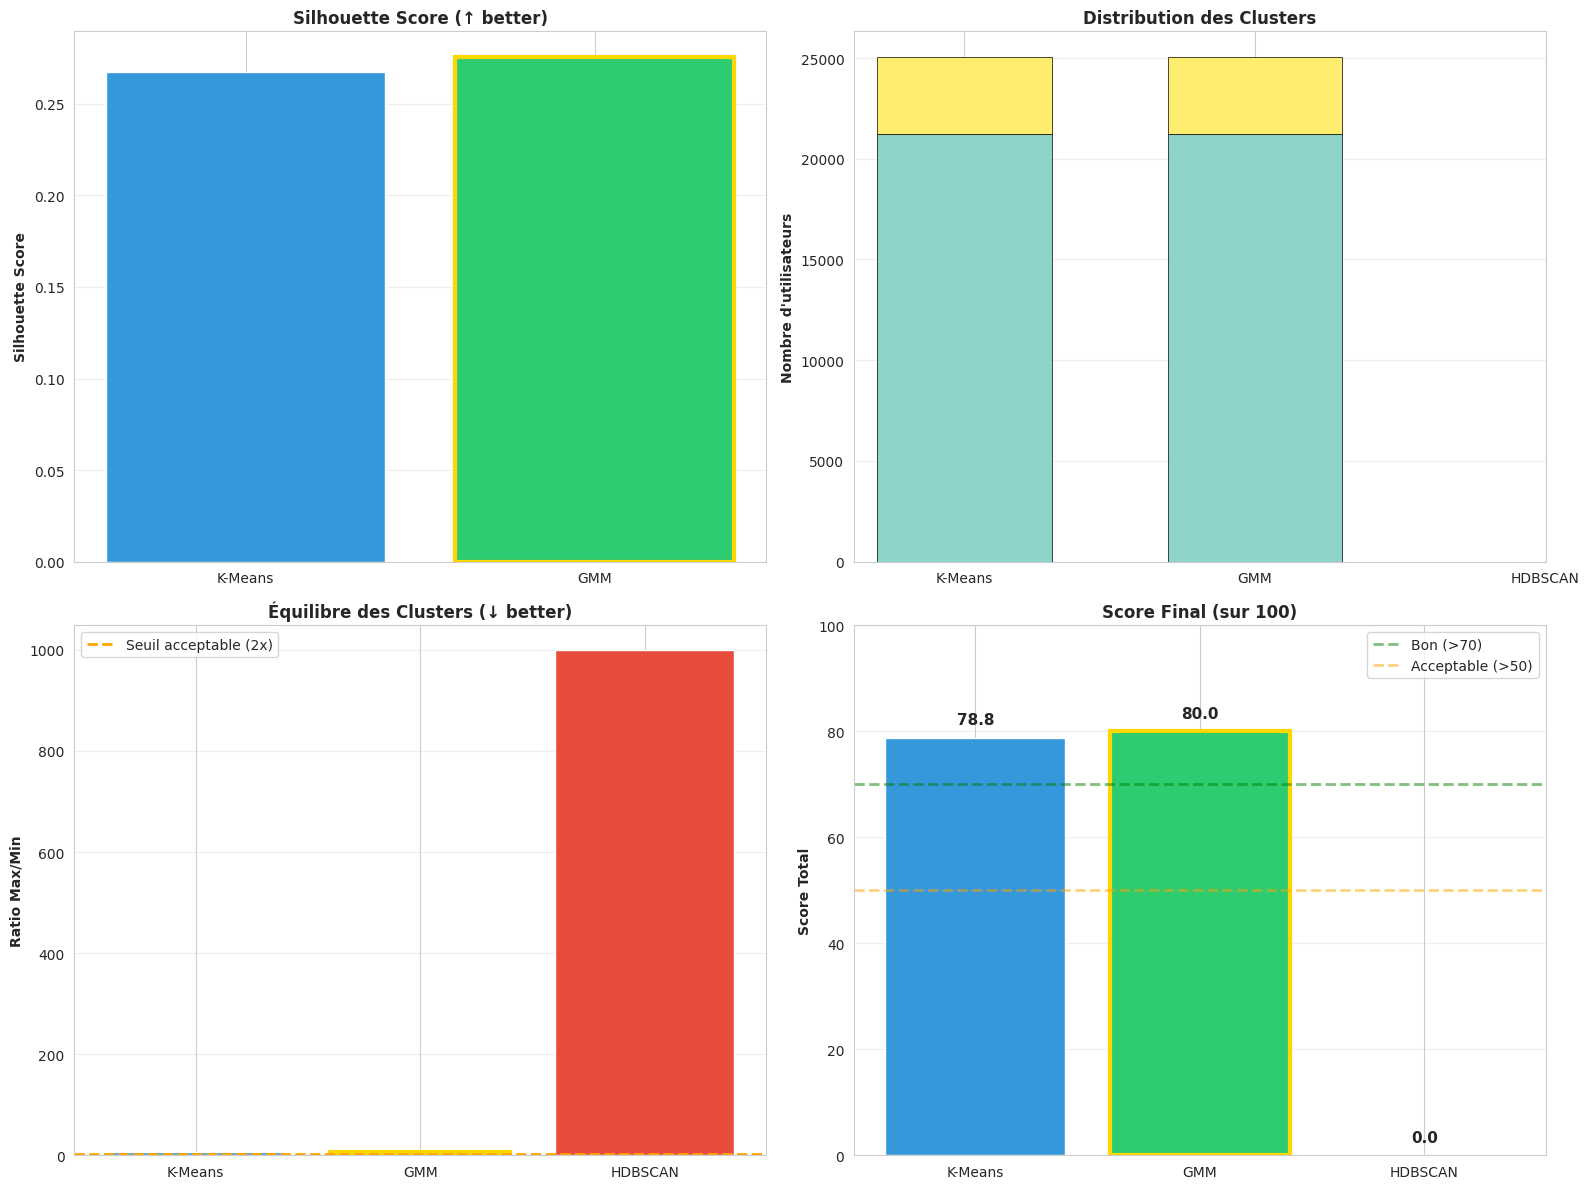

✅ Comparaison métriques sauvegardée: ../outputs/figures/05_comparison_metrics.png

✅ Toutes les visualisations comparatives sont prêtes !


In [40]:
print("=" * 80)
print("VISUALISATIONS COMPARATIVES")
print("=" * 80)

# Préparer les données pour visualisation
models_to_plot = [
    ('K-Means', kmeans_results['clusters'], kmeans_results['n_clusters']),
    ('GMM', gmm_results['clusters'], gmm_results['n_clusters']),
    ('HDBSCAN', hdbscan_results['clusters'], hdbscan_results['n_clusters'])
]

# PCA pour réduction à 2D (déjà calculé avant)
if 'cluster' in features_scaled_df.columns:
    features_for_pca = features_scaled_df.drop('cluster', axis=1)
else:
    features_for_pca = features_scaled_df

pca_comparison = PCA(n_components=2)
features_pca_comp = pca_comparison.fit_transform(features_for_pca)

# 1. Comparaison PCA des 3 modèles
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, (model_name, clusters, n_clust) in enumerate(models_to_plot):
    ax = axes[idx]
    
    # Gérer HDBSCAN avec bruit
    unique_clusters = sorted(set(clusters))
    if -1 in unique_clusters:
        # Tracer le bruit en gris
        mask_noise = clusters == -1
        ax.scatter(features_pca_comp[mask_noise, 0], features_pca_comp[mask_noise, 1],
                  c='lightgray', alpha=0.3, s=20, label='Bruit', edgecolors='none')
        unique_clusters = [c for c in unique_clusters if c != -1]
    
    # Tracer les clusters
    colors = plt.cm.tab10(np.linspace(0, 1, max(10, n_clust)))
    for cluster_id in unique_clusters:
        mask = clusters == cluster_id
        count = mask.sum()
        ax.scatter(features_pca_comp[mask, 0], features_pca_comp[mask, 1],
                  label=f'C{cluster_id} ({count:,})',
                  alpha=0.6, s=30, color=colors[cluster_id % len(colors)],
                  edgecolors='black', linewidth=0.2)
    
    ax.set_xlabel(f'PC1 ({pca_comparison.explained_variance_ratio_[0]:.1%})', fontweight='bold')
    ax.set_ylabel(f'PC2 ({pca_comparison.explained_variance_ratio_[1]:.1%})', fontweight='bold')
    
    # Afficher la silhouette dans le titre
    sil = final_best_results['silhouette'] if model_name == best_model else (
        kmeans_results['silhouette'] if model_name == 'K-Means' else (
            gmm_results['silhouette'] if model_name == 'GMM' else hdbscan_results['silhouette']
        )
    )
    
    title = f'{model_name}'
    if model_name == best_model:
        title += ' 🏆'
    title += f'\nK={n_clust}, Sil={sil:.3f}'
    
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUTS_FIGURES / '04_comparison_pca.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Comparaison PCA sauvegardée: {OUTPUTS_FIGURES / '04_comparison_pca.png'}")

# 2. Graphique comparatif des métriques
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Silhouette Scores
ax = axes[0, 0]
valid_models = []
valid_silhouettes = []
for model in models:
    if model == 'HDBSCAN' and hdbscan_results['silhouette'] <= 0:
        continue
    valid_models.append(model)
    valid_silhouettes.append(scores[model]['silhouette'] / 40)  # Dénormaliser

if valid_silhouettes:
    bars = ax.bar(valid_models, [kmeans_results['silhouette'], gmm_results['silhouette'], 
                                   hdbscan_results['silhouette'] if hdbscan_results['silhouette'] > 0 else 0][:len(valid_models)],
                  color=['#3498db', '#2ecc71', '#e74c3c'][:len(valid_models)])
    ax.set_ylabel('Silhouette Score', fontweight='bold')
    ax.set_title('Silhouette Score (↑ better)', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    # Marquer le meilleur
    for i, model in enumerate(valid_models):
        if model == best_model:
            bars[i].set_edgecolor('gold')
            bars[i].set_linewidth(3)

# Distribution des clusters
ax = axes[0, 1]
cluster_counts = [len(models_to_plot[i][1]) for i in range(3)]
x_pos = np.arange(len(models))
for i, (model_name, clusters, n_clust) in enumerate(models_to_plot):
    dist = pd.Series(clusters).value_counts().sort_index()
    # Exclure le bruit pour HDBSCAN
    if -1 in dist.index:
        dist = dist.drop(-1)
    
    x_offset = x_pos[i]
    colors_dist = plt.cm.Set3(np.linspace(0, 1, len(dist)))
    bottom = 0
    for j, (clust_id, count) in enumerate(dist.items()):
        ax.bar(x_offset, count, bottom=bottom, color=colors_dist[j], 
              edgecolor='black', linewidth=0.5, width=0.6)
        bottom += count

ax.set_xticks(x_pos)
ax.set_xticklabels(models)
ax.set_ylabel('Nombre d\'utilisateurs', fontweight='bold')
ax.set_title('Distribution des Clusters', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Équilibre (Ratio Max/Min)
ax = axes[1, 0]
balances = [kmeans_balance, gmm_balance, hdbscan_balance]
bars = ax.bar(models, balances, color=['#3498db', '#2ecc71', '#e74c3c'])
ax.set_ylabel('Ratio Max/Min', fontweight='bold')
ax.set_title('Équilibre des Clusters (↓ better)', fontsize=12, fontweight='bold')
ax.axhline(y=2, color='orange', linestyle='--', linewidth=2, label='Seuil acceptable (2x)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
# Marquer le meilleur
best_balance_idx = models.index(best_model)
bars[best_balance_idx].set_edgecolor('gold')
bars[best_balance_idx].set_linewidth(3)

# Scores finaux
ax = axes[1, 1]
final_scores = [scores[m]['total'] for m in models]
bars = ax.bar(models, final_scores, color=['#3498db', '#2ecc71', '#e74c3c'])
ax.set_ylabel('Score Total', fontweight='bold')
ax.set_ylim(0, 100)
ax.set_title('Score Final (sur 100)', fontsize=12, fontweight='bold')
ax.axhline(y=70, color='green', linestyle='--', linewidth=2, alpha=0.5, label='Bon (>70)')
ax.axhline(y=50, color='orange', linestyle='--', linewidth=2, alpha=0.5, label='Acceptable (>50)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
# Marquer le gagnant
best_idx = models.index(best_model)
bars[best_idx].set_edgecolor('gold')
bars[best_idx].set_linewidth(3)
# Ajouter les valeurs sur les barres
for i, (bar, score) in enumerate(zip(bars, final_scores)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 2,
           f'{score:.1f}',
           ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig(OUTPUTS_FIGURES / '05_comparison_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Comparaison métriques sauvegardée: {OUTPUTS_FIGURES / '05_comparison_metrics.png'}")
print("\n✅ Toutes les visualisations comparatives sont prêtes !")

## 💾 Export Final avec le Meilleur Modèle

In [41]:
print("=" * 80)
print(f"💾 EXPORT FINAL AVEC LE MODÈLE {best_model}")
print("=" * 80)

# Créer le DataFrame final avec les clusters du meilleur modèle
user_profiles_final = user_profiles.copy()

# Supprimer l'ancienne colonne cluster si elle existe
if 'cluster' in user_profiles_final.columns:
    user_profiles_final = user_profiles_final.drop('cluster', axis=1)

# Ajouter les nouveaux clusters
user_profiles_final['cluster'] = final_clusters
user_profiles_final['clustering_model'] = best_model

# Si GMM, ajouter les probabilités
if best_model == 'GMM':
    # Ajouter la confiance de l'assignment
    max_proba = gmm_results['probabilities'].max(axis=1)
    user_profiles_final['cluster_confidence'] = max_proba
    
    print(f"\nINFORMATIONS GMM:")
    print(f"   • Colonne 'cluster_confidence' ajoutée")
    print(f"   • Confiance moyenne: {max_proba.mean():.1%}")
    print(f"   • Min: {max_proba.min():.1%}, Max: {max_proba.max():.1%}")

# Export
output_file = DATA_PROCESSED / 'users_profiles_clustered.csv'
user_profiles_final.to_csv(output_file, index=False)

print(f"\n✅ FICHIER EXPORTÉ:")
print(f"   • Chemin: {output_file}")
print(f"   • Shape: {user_profiles_final.shape}")
print(f"   • Taille: {output_file.stat().st_size / 1024 / 1024:.2f} MB")

print(f"\n📋 COLONNES ({len(user_profiles_final.columns)}):")
for i, col in enumerate(user_profiles_final.columns, 1):
    print(f"   {i:2d}. {col}")

print(f"\nDISTRIBUTION FINALE ({best_model}):")
final_dist = user_profiles_final['cluster'].value_counts().sort_index()
for cluster_id, count in final_dist.items():
    if cluster_id == -1:
        print(f"   Bruit (-1): {count:>8,} ({100*count/len(user_profiles_final):>5.1f}%)")
    else:
        pct = 100 * count / len(user_profiles_final)
        print(f"   Cluster {cluster_id}: {count:>8,} ({pct:>5.1f}%)")

print(f"\n✅ Dataset avec clusters {best_model} prêt pour analyse et recommandations!")

💾 EXPORT FINAL AVEC LE MODÈLE GMM

INFORMATIONS GMM:
   • Colonne 'cluster_confidence' ajoutée
   • Confiance moyenne: 100.0%
   • Min: 100.0%, Max: 100.0%



✅ FICHIER EXPORTÉ:
   • Chemin: ../data/processed/users_profiles_clustered.csv
   • Shape: (25076, 23)
   • Taille: 5.04 MB

📋 COLONNES (23):
    1. user_id
    2. n_interactions
    3. avg_rating
    4. avg_minutes
    5. avg_n_steps
    6. avg_n_ingredients
    7. avg_calories
    8. avg_total_fat
    9. avg_sugar
   10. avg_sodium
   11. avg_protein
   12. avg_saturated_fat
   13. avg_carbohydrates
   14. pref_tag_time_to_make
   15. pref_tag_course
   16. pref_tag_main_ingredient
   17. pref_tag_dietary
   18. pref_tag_easy
   19. pref_tag_occasion
   20. pref_tag_cuisine
   21. cluster
   22. clustering_model
   23. cluster_confidence

DISTRIBUTION FINALE (GMM):
   Cluster 0:   21,249 ( 84.7%)
   Cluster 1:    3,827 ( 15.3%)

✅ Dataset avec clusters GMM prêt pour analyse et recommandations!


## 📋 Synthèse Finale - Comparaison des Modèles

In [42]:
print("\n" + "=" * 80)
print("🎉 SYNTHÈSE FINALE - COMPARAISON DES MODÈLES DE CLUSTERING")
print("=" * 80)

print(f"\n🎯 OBJECTIF:")
print(f"   Comparer 3 algorithmes pour segmenter les utilisateurs en profils culinaires")

print(f"\nDONNÉES:")
print(f"   • Utilisateurs: {len(user_profiles):,}")
print(f"   • Features: {len(features_cols)}")

print(f"\n🔬 MODÈLES TESTÉS:")
print(f"   1. K-Means (clustering par centroïdes)")
print(f"   2. GMM - Gaussian Mixture (clustering probabiliste)")
print(f"   3. HDBSCAN (clustering par densité)")

print(f"\nRÉSULTATS COMPARATIFS:")
print(f"\n   K-Means:")
print(f"      • Clusters: {kmeans_results['n_clusters']}")
print(f"      • Silhouette: {kmeans_results['silhouette']:.4f}")
print(f"      • Équilibre: {kmeans_balance:.2f}x")
print(f"      • Score final: {scores['K-Means']['total']:.1f}/100")

print(f"\n   GMM:")
print(f"      • Clusters: {gmm_results['n_clusters']}")
print(f"      • Silhouette: {gmm_results['silhouette']:.4f}")
print(f"      • Équilibre: {gmm_balance:.2f}x")
print(f"      • Confiance: {gmm_results['mean_confidence']:.1%}")
print(f"      • Score final: {scores['GMM']['total']:.1f}/100")

print(f"\n   HDBSCAN:")
print(f"      • Clusters: {hdbscan_results['n_clusters']}")
if hdbscan_results['silhouette'] > 0:
    print(f"      • Silhouette: {hdbscan_results['silhouette']:.4f}")
else:
    print(f"      • Silhouette: N/A")
print(f"      • Équilibre: {hdbscan_balance:.2f}x")
print(f"      • Bruit: {hdbscan_results['noise_pct']:.1f}%")
print(f"      • Score final: {scores['HDBSCAN']['total']:.1f}/100")

print(f"\n🏆 MODÈLE SÉLECTIONNÉ: {best_model}")
print(f"   • Score: {scores[best_model]['total']:.1f}/100")
print(f"   • Nombre de clusters: {final_best_results['n_clusters']}")
print(f"   • Silhouette: {final_best_results['silhouette']:.4f}")

print(f"\n📦 FICHIERS GÉNÉRÉS:")
print(f"   1. users_profiles_clustered.csv (avec modèle {best_model})")
print(f"   2. 01_elbow_silhouette.png (K-Means)")
print(f"   3. 02_cluster_profiles_heatmap.png")
print(f"   4. 03_clusters_pca.png")
print(f"   5. 04_comparison_pca.png (comparaison 3 modèles)")
print(f"   6. 05_comparison_metrics.png (métriques comparatives)")

print(f"\n💡 INSIGHTS:")
if best_model == 'K-Means':
    print(f"   • K-Means a été sélectionné malgré sa simplicité")
    print(f"   • Les clusters sphériques conviennent bien aux données")
elif best_model == 'GMM':
    print(f"   • GMM offre une meilleure séparation probabiliste")
    print(f"   • Les distributions gaussiennes capturent mieux la structure des données")
    print(f"   • La confiance des assignments peut guider les recommandations")
else:  # HDBSCAN
    print(f"   • HDBSCAN a identifié les véritables groupes denses")
    print(f"   • Les points de bruit peuvent être traités séparément")
    print(f"   • Clustering plus naturel sans imposer K")

print(f"\n🎯 PROCHAINES ÉTAPES:")
print(f"   1. Interpréter les profils culinaires de chaque cluster")
print(f"   2. Nommer les segments (ex: 'Gourmand', 'Healthy', 'Rapide', etc.)")
print(f"   3. Créer système de recommandations basé sur {best_model}")
print(f"   4. Valider avec métriques business")

print("=" * 80)


🎉 SYNTHÈSE FINALE - COMPARAISON DES MODÈLES DE CLUSTERING

🎯 OBJECTIF:
   Comparer 3 algorithmes pour segmenter les utilisateurs en profils culinaires

DONNÉES:
   • Utilisateurs: 25,076
   • Features: 19

🔬 MODÈLES TESTÉS:
   1. K-Means (clustering par centroïdes)
   2. GMM - Gaussian Mixture (clustering probabiliste)
   3. HDBSCAN (clustering par densité)

RÉSULTATS COMPARATIFS:

   K-Means:
      • Clusters: 2
      • Silhouette: 0.2676
      • Équilibre: 5.55x
      • Score final: 78.8/100

   GMM:
      • Clusters: 2
      • Silhouette: 0.2759
      • Équilibre: 5.55x
      • Confiance: 100.0%
      • Score final: 80.0/100

   HDBSCAN:
      • Clusters: 0
      • Silhouette: N/A
      • Équilibre: 999.00x
      • Bruit: 100.0%
      • Score final: 0.0/100

🏆 MODÈLE SÉLECTIONNÉ: GMM
   • Score: 80.0/100
   • Nombre de clusters: 2
   • Silhouette: 0.2759

📦 FICHIERS GÉNÉRÉS:
   1. users_profiles_clustered.csv (avec modèle GMM)
   2. 01_elbow_silhouette.png (K-Means)
   3. 02_cluste